### Week-5 task
#### 1.Clustering Netflix titles by genre, duration, and rating
#### 2.Classification of content type (Movie vs TV Show)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object    

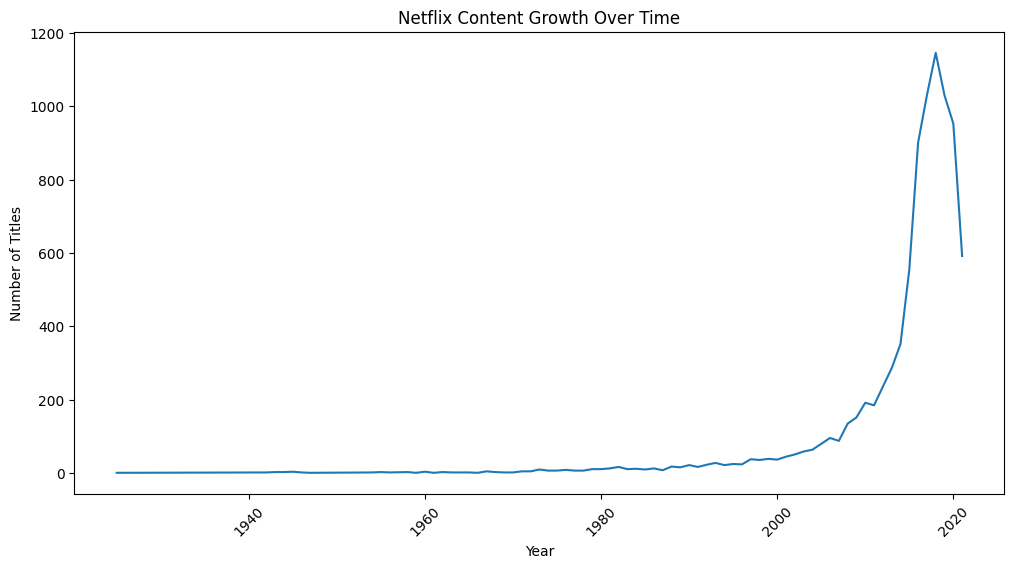

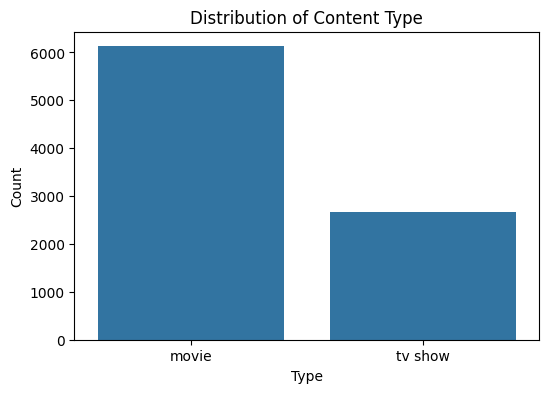

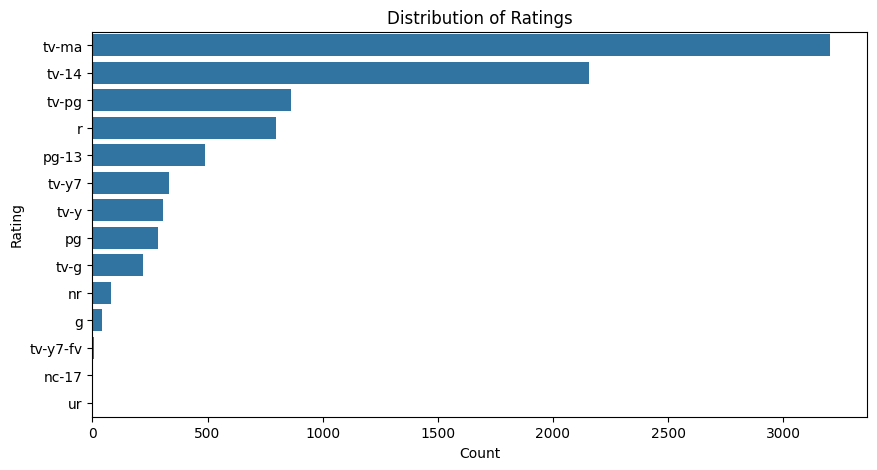

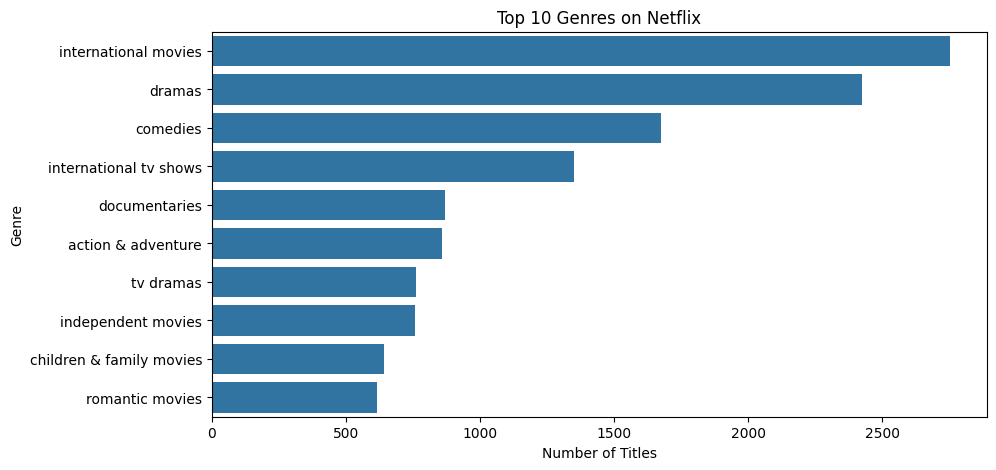

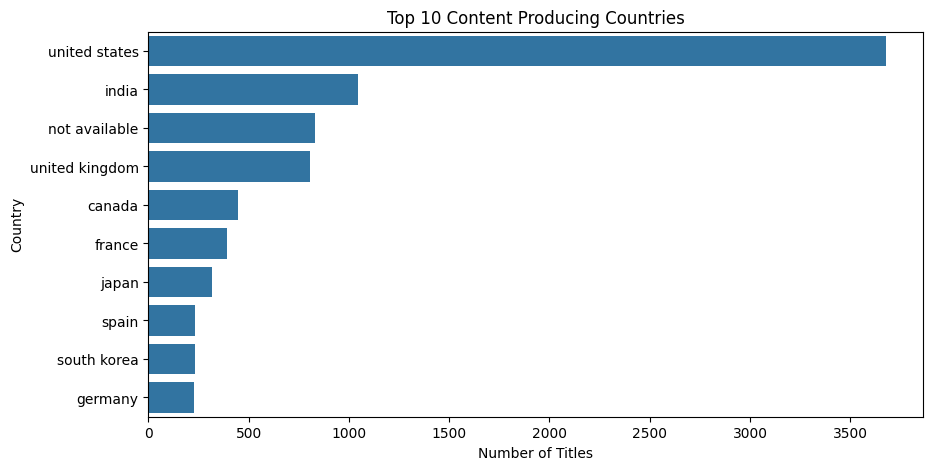

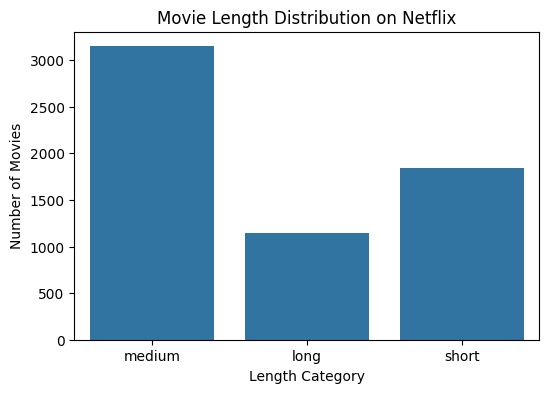

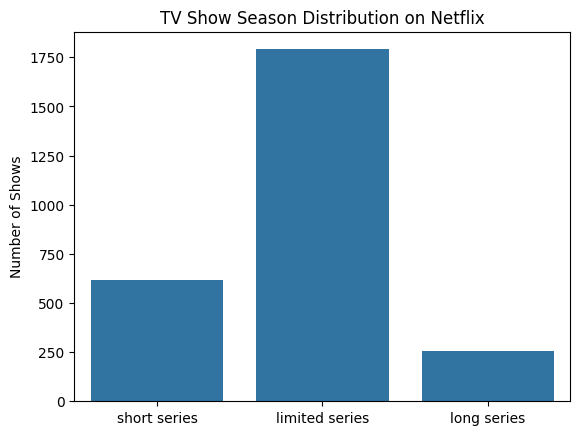

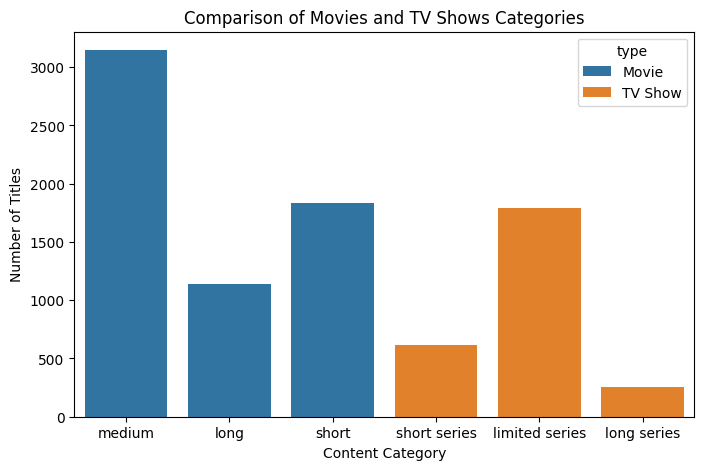

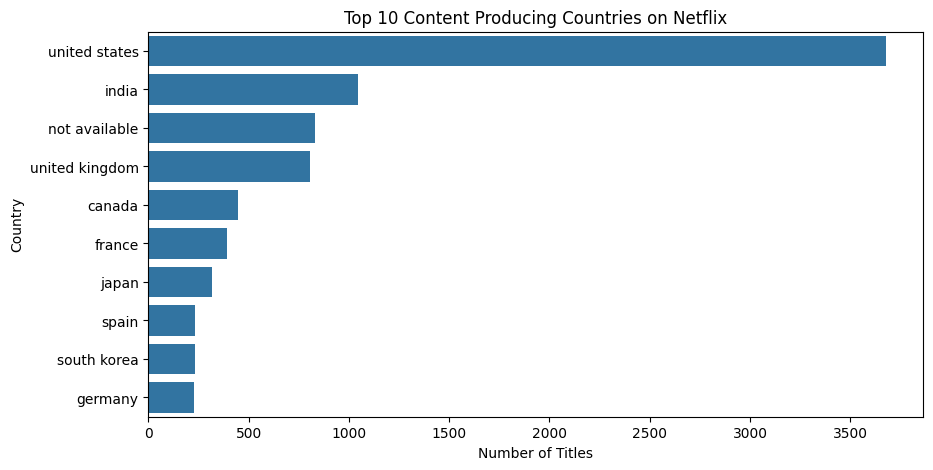

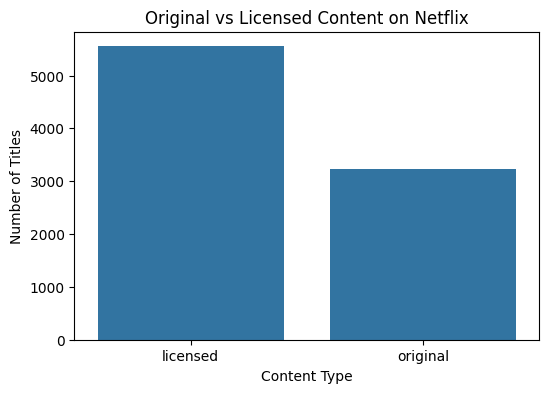

In [1]:
%run week_4.ipynb

#### 1.Clustering Netflix titles by genre, duration, and rating

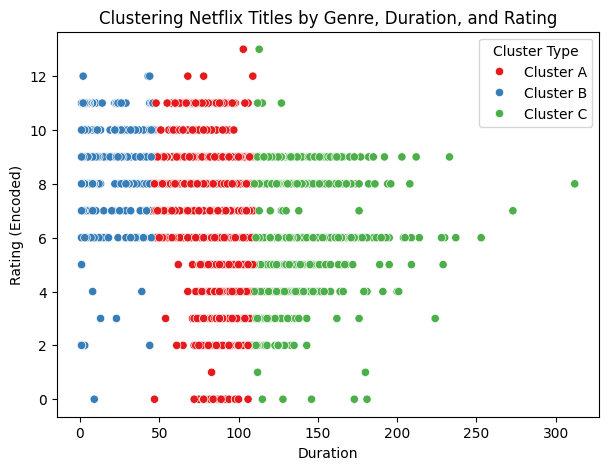

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

# Extract numeric duration
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Take first genre
df['genre'] = df['listed_in'].str.split(',').str[0]

# Encode categorical variables
le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'])
df['genre_encoded'] = le.fit_transform(df['genre'])

# Prepare feature dataset
X = df[['duration_num','rating_encoded','genre_encoded']].dropna()

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster numbers
X['cluster'] = clusters

# Give names to clusters
cluster_labels = {
    0: "Cluster A",
    1: "Cluster B",
    2: "Cluster C"
}

# Map cluster numbers to names
X['cluster_label'] = X['cluster'].map(cluster_labels)

# Plot clusters
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X['duration_num'],
    y=X['rating_encoded'],
    hue=X['cluster_label'],
    palette='Set1'
)

plt.title("Clustering Netflix Titles by Genre, Duration, and Rating")
plt.xlabel("Duration")
plt.ylabel("Rating (Encoded)")
plt.legend(title="Cluster Type")
plt.show()

#### Cluster Distribution (How many titles in each cluster)

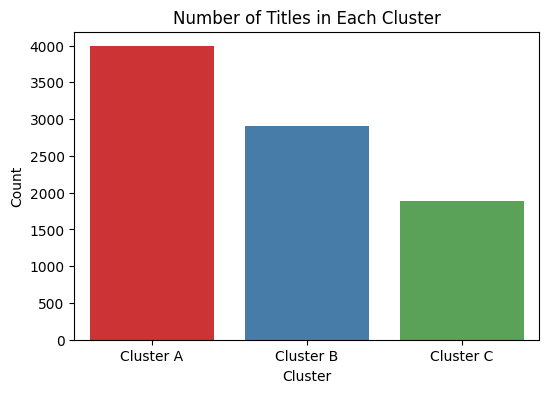

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='cluster_label', hue='cluster_label', data=X, palette='Set1', legend=False)

plt.title("Number of Titles in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

#### Duration vs Genre Clusters

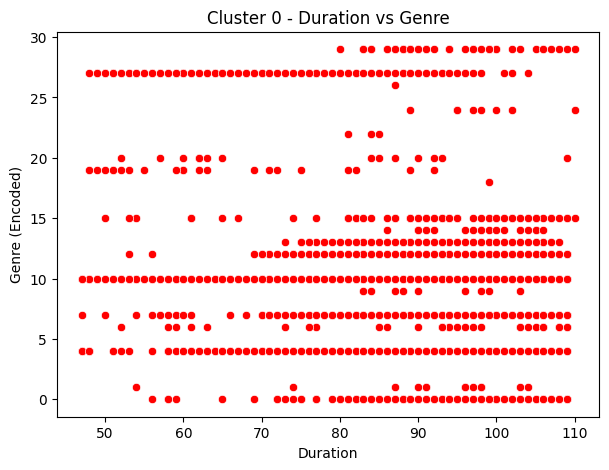

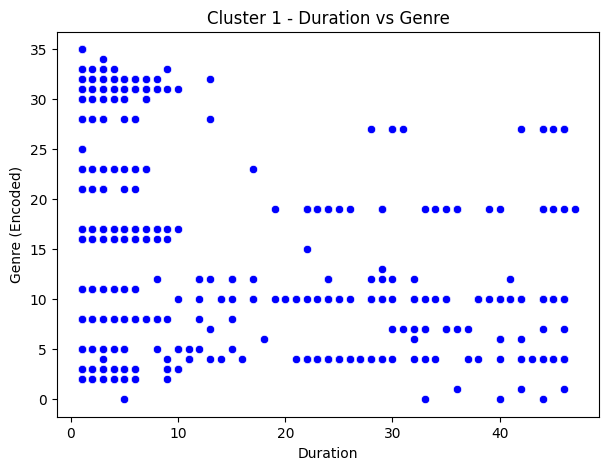

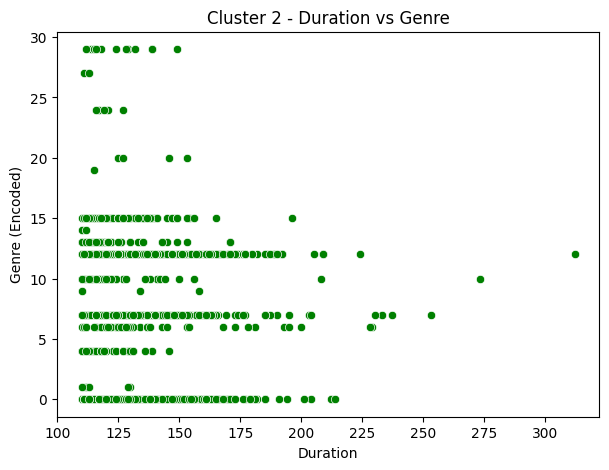

In [13]:
colors = ['red', 'blue', 'green']

for i in range(3):
    plt.figure(figsize=(7,5))
    
    cluster_data = X[clusters == i]
    
    sns.scatterplot(
        x=cluster_data['duration_num'],
        y=cluster_data['genre_encoded'],
        color=colors[i]
    )
    
    plt.title(f"Cluster {i} - Duration vs Genre")
    plt.xlabel("Duration")
    plt.ylabel("Genre (Encoded)")
    
    plt.show()

### 2.Classification of content type (Movie vs TV Show)

In [15]:
y = df['type']
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
X = df[['duration_num','rating_encoded','genre_encoded']].fillna(0)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



#### Confusion Matrix

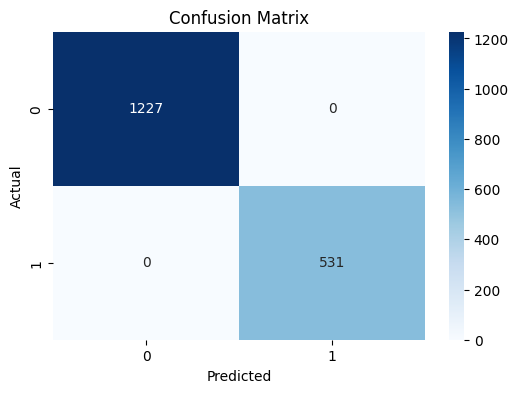

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Feature Importance Plot

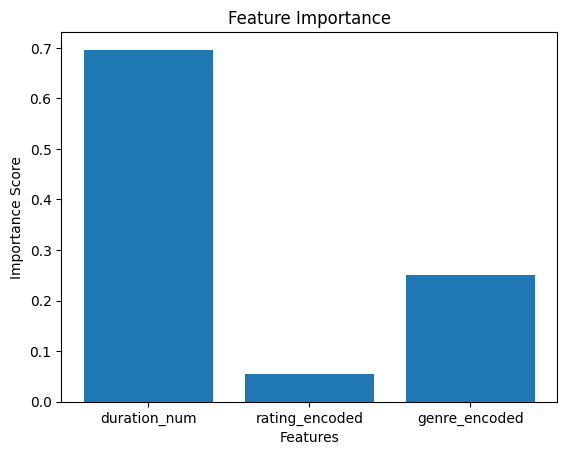

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show() 

#### Class Distribution Plot

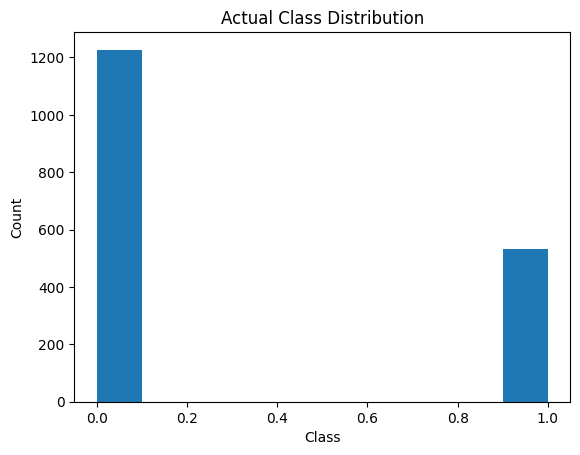

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y_test)
plt.title("Actual Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#### Predicted Comparison

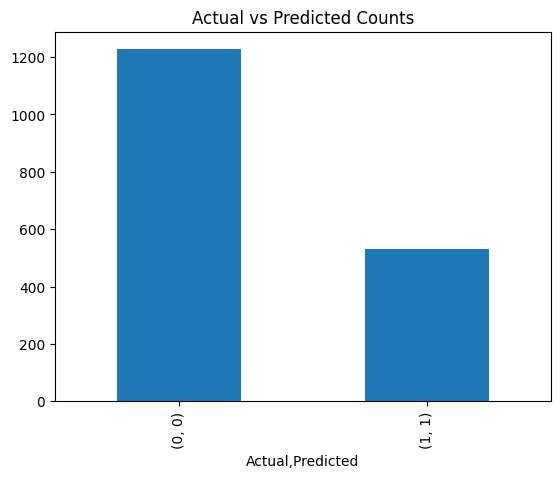

In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.value_counts().plot(kind="bar")
plt.title("Actual vs Predicted Counts")
plt.show()